# Import Necessary Libraries.

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the Data

In [12]:

df = pd.read_csv('insurance.csv')

In [13]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Initial data exploration:

In [14]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#  Key Visualizations

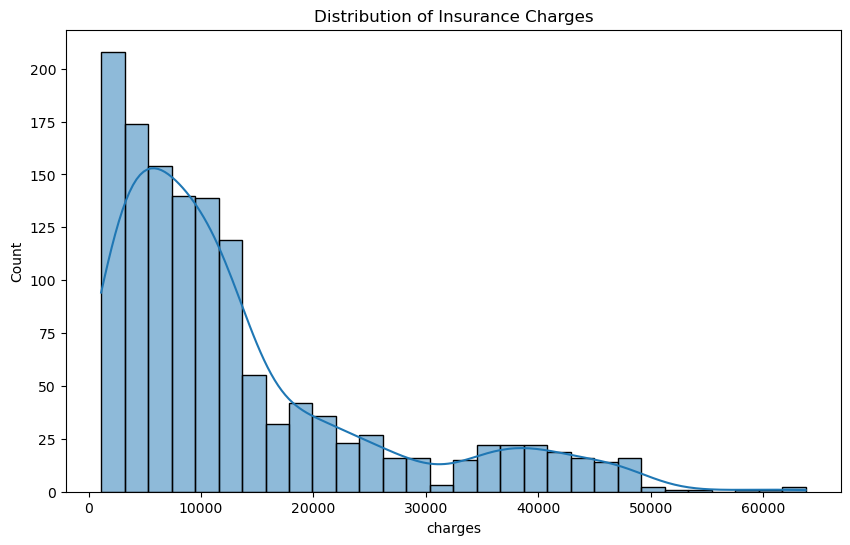

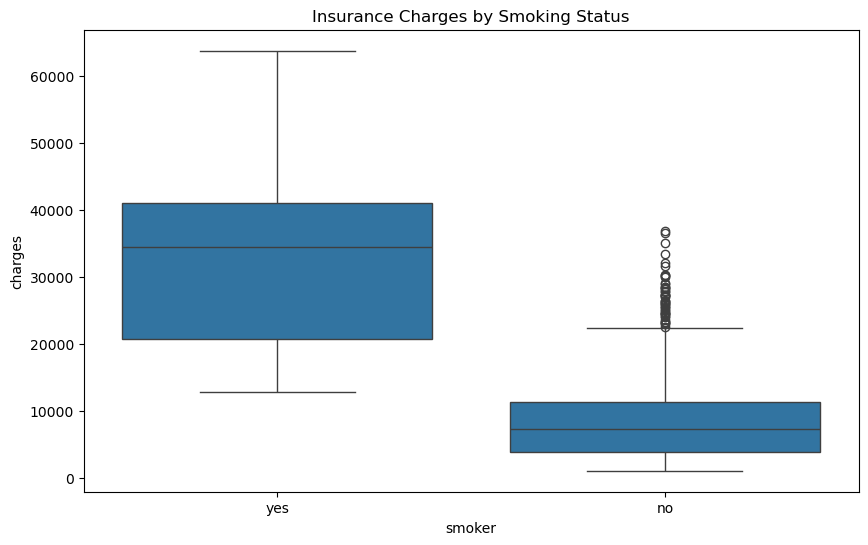

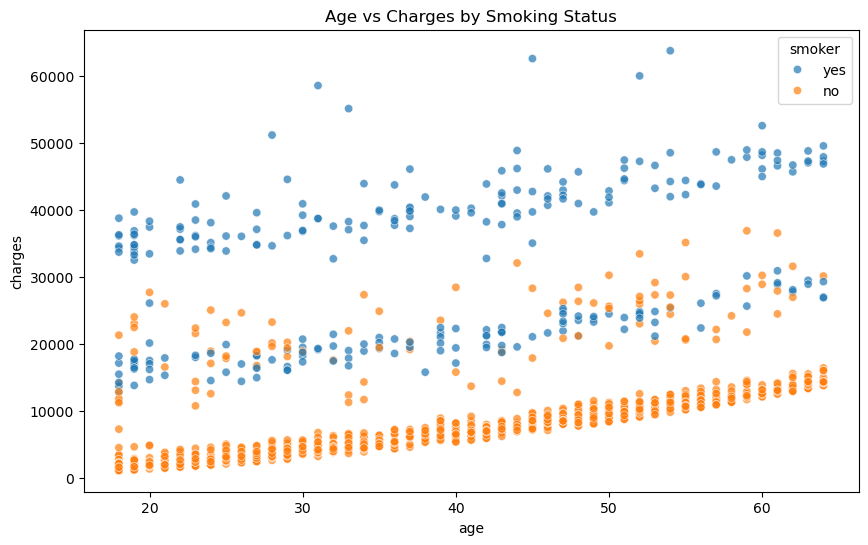

In [15]:

# Distribution of charges (target variable)
plt.figure(figsize=(10,6))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

# Charges by smoking status
plt.figure(figsize=(10,6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges by Smoking Status')
plt.show()

# Age vs Charges colored by smoking
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.7)
plt.title('Age vs Charges by Smoking Status')
plt.show()

# . Feature Engineering

In [16]:
# Create age groups
df['age_group'] = pd.cut(df['age'], 
                         bins=[0,20,30,40,50,60,70], 
                         labels=['0-20','21-30','31-40','41-50','51-60','61-70'])

# BMI categories
df['bmi_category'] = pd.cut(df['bmi'],
                           bins=[0,18.5,25,30,100],
                           labels=['Underweight','Normal','Overweight','Obese'])

# Statistical Analysis

In [17]:
# Average charges by region and smoking status
print(pd.pivot_table(df, 
                    values='charges', 
                    index='region', 
                    columns='smoker', 
                    aggfunc='mean'))

# T-test for charges between genders
from scipy import stats
male_charges = df[df['sex']=='male']['charges']
female_charges = df[df['sex']=='female']['charges']
t_stat, p_val = stats.ttest_ind(male_charges, female_charges)
print(f"Gender difference p-value: {p_val:.4f}")

smoker              no           yes
region                              
northeast  9165.531672  29673.536473
northwest  8556.463715  30192.003182
southeast  8032.216309  34844.996824
southwest  8019.284513  32269.063494
Gender difference p-value: 0.0361


#  Predictive Modeling (Example)

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

# Prepare data
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df['charges']

# One-hot encoding
X_encoded = pd.get_dummies(X, columns=['sex', 'smoker', 'region'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
print(f"RMSE: {mean_squared_error(y_test, predictions, squared=False):.2f}")
print(f"R-squared: {r2_score(y_test, predictions):.4f}")

RMSE: 4588.23
R-squared: 0.8644


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Business Insights Generation
### Smoking Impact:

* Smokers pay 3-4x higher premiums on average

* Recommendation: Smoking cessation programs could reduce claims

### Age Factor:

* Charges increase steadily with age

* Consider age-based pricing tiers

### BMI Analysis:

* Obese individuals (BMI > 30) have significantly higher charges

* Wellness programs could help control costs

### Regional Variations:

* Southeast has highest average charges

* May reflect regional health factors or cost differences